In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
print(df.head())
df.info()
df.isnull().sum()

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

**Gender ENCODING**

In [3]:
df['Gender'] = df['Gender'].map({'Male':0,'Female':1})
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


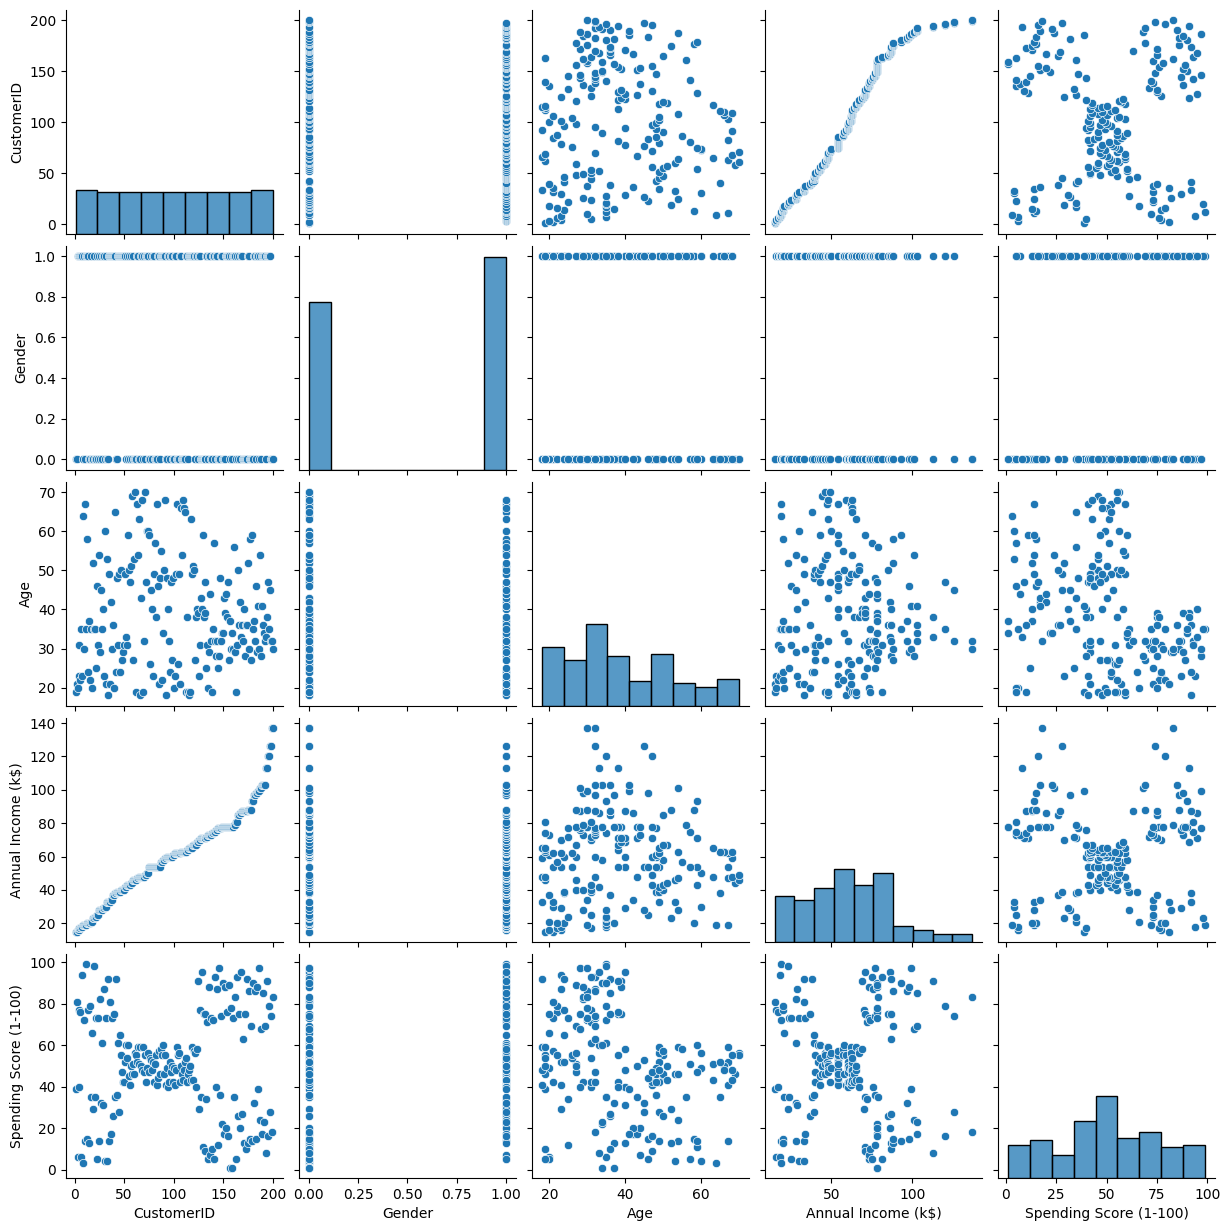

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df)
plt.show()

As we could only see clustered relation between Annual Income and Spending  Score we will use them only

In [5]:
from sklearn.preprocessing import StandardScaler
X = df[['Annual Income (k$)', 'Spending Score (1-100)']] 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.cluster import KMeans

kmeans= KMeans(n_clusters=5, random_state= 42)
y_kmeans= kmeans.fit_predict(X_scaled)

In [7]:
df['Clusters'] = y_kmeans

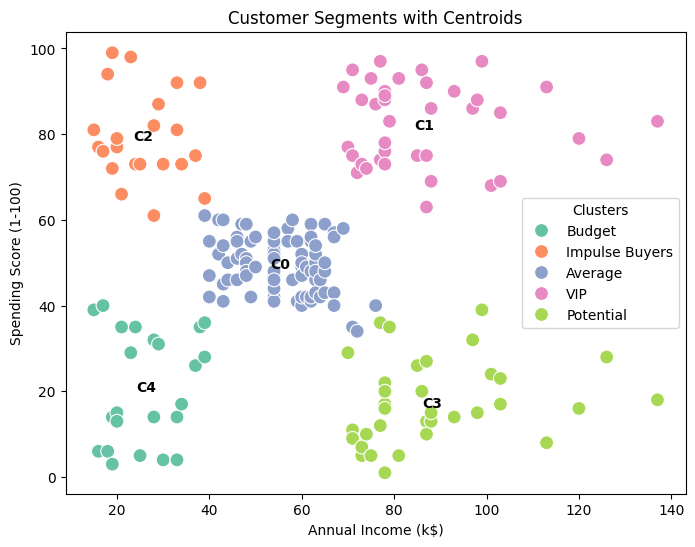

In [8]:
cluster_labels = {
    0: 'Average',
    1: 'VIP',
    2: 'Impulse Buyers',
    3: 'Potential',
    4: 'Budget'
}
df['Cluster_Label'] = df['Clusters'].map(cluster_labels)

# Get centroids (original scale for plotting)
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster_Label',
    data=df,
    palette='Set2',
    s=100,
    legend='full'
)

# Add labeled centroids (small, clean)
for i, centroid in enumerate(centroids_original):
    plt.text(
        centroid[0],
        centroid[1],
        f'C{i}',
        fontsize=10,
        fontweight='bold',
        ha='center',
        va='center',
        color='black'
    )

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments with Centroids')
plt.legend(title='Clusters')
plt.show()

In [9]:
# Cluster profiling
summary = df.groupby('Cluster_Label').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': ['mean', 'min', 'max'],
    'Gender': lambda x: x.value_counts().to_dict(),
    'Clusters': 'count'
})

summary

Annual Income (k$) Spending Score (1-100)        Age          \
                             mean                   mean       mean min max   
Cluster_Label                                                                 
Average                 55.296296              49.518519  42.716049  18  70   
Budget                  26.304348              20.913043  45.217391  19  67   
Impulse Buyers          25.727273              79.363636  25.272727  18  35   
Potential               88.200000              17.114286  41.114286  19  59   
VIP                     86.538462              82.128205  32.692308  27  40   

                        Gender Clusters  
                      <lambda>    count  
Cluster_Label                            
Average         {1: 48, 0: 33}       81  
Budget           {1: 14, 0: 9}       23  
Impulse Buyers   {1: 13, 0: 9}       22  
Potential       {0: 19, 1: 16}       35  
VIP             {1: 21, 0: 18}       39

# Customer Segmentation Summary
**Objective**

Segment mall customers based on Annual Income and Spending Score to identify target groups for marketing.

**Data Overview**
Features used: Annual Income, Spending Score, Age, Gender
Gender encoded: Male = 0, Female = 1
No missing values

**Clustering**
Algorithm: K-Means (5 clusters)
Features for clustering: Annual Income & Spending Score
Centroids visualized in scatter plot

**Key Takeaways**
Income & Spending Score drive clusters; Age & Gender help profile them.
Each cluster has clear marketing strategies, making the segmentation actionable and practical for business.